In [ ]:
import matplotlib.pyplot as plt
import numpy as np

from sklearn.linear_model import Perceptron                                                                                                                                                                                                                                                                                                                                                                                                                     

# 퍼셉트론 알고리즘

## 1. 개요 요약

### 1.1 정의

- 선형 분류 위한 기본적인 알고리즘 (지도학습, 분류)
- 데이터를 분류하는 ‘선형 경계면’에 대한 학습
- 입력 벡터와 학습한 가중치 벡터를 곱한 값을 합한 값이 0 이상일 때는 클래스 1로, 미만일 때는 클래스 2로 분류 (1/0, 1/-1도 흔히 사용)
- 선형점수: $f(x) = w^\top x + b$
- 결정 경계식: $f(x) = 0$
- 신경망 알고리즘의 기초

### 1.2 특징

- 온라인 학습 방법(SGD, 경사적 하강 학습법) 취함
- 과대적합에 취약
- 선형분리불가능한 데이터 적용 불가 ex) 배타적 논리합(XOR) 적용 불가
- 학습이 빠르지만, 예측 성능은 보통 수준

### 1.3 모델 학습 원리와 방식

#### 1.3.1 손실함수(loss function)

- 힌지 손실(hinge loss) 사용

$$
\max(0, -t_i(w^\top x_i + b))
$$

- $t_i$: 타깃 라벨
- $w$: 가중치
- $x_i$: 입력 데이터
- $b$: 편향

- 퍼셉트론 규준: 퍼셉트론에 사용되는 힌지 손실

![퍼셉트론 규준](./perceptron_criterion.png)

그림 설명: 정분류일시 손실은 0이 되며, 오분류일시 손실은 양의 값으로 선형 증가한다.

#### 1.3.2 목적함수(objective function)

- 힌지 손실의 일반화
- 퍼셉트론의 목적함수: 모든 데이터에 대한 힌지 손실의 합

$$
L(w,b) = \sum_{i=1}^{n} \max(0, -t_i(w^\top x_i + b))
$$

#### 1.3.3 손실값의 최소화: 목적 함수의 최소화

- 오분류 데이터 수가 가능한 작아지게 되며, 이때의 가중치가 최적 파라미터
- 모델의 학습은 이 때의 가중치가 되도록 학습

#### 1.3.4 학습 방식: 확률적 경사 하강법(SGD, stochastic gradient descent)

- 목적 함수로부터 경사가 심한 쪽으로 ‘조금씩’ 내려가며 파라미터 수정하는 학습법
- 모든 데이터에 대해 한꺼번에 학습하는 ‘배치(batch)학습’과 달리 산 위에서 경사가 심한, 가장 빠른 길로 천천히 골짜기 방향으로 내려감
- 해의 (비)수렴: SGD로 목적 함수의 최솟값 (비) 달성

#### 1.3.5 학습률(기호 에타)

- 파라미터($w$, $b$)의 수정 폭 결정
- 수정폭 = 학습률 × 기울기

$$
\text{수정폭} = \eta \times \text{기울기}
$$

- 학습률(+): 수렴 시간 단축, 비수렴 가능성 증대(수정폭 커서 최솟값 지나칠 가능성)
- 학습률(-): 수렴 가능성 증대, 수렴 비효율성 증가(수정폭 작아 반복횟수 증가 가능성)

#### 1.3.6 활성화 함수(activation function)

- 일종의 계단함수
- 입력값(선형점수와 타깃 라벨의 곱의 부호)을 비선형 변환하는 함수(+1/-1)

![계단 함수](./step_function.png)

## 2. 상세

### 2.1 선형 점수 함수

$$
f(x) = w^\top x + b
$$

| 기호 | 의미 |
|---|---|
| $x$ | 입력 벡터 |
| $w$ | 가중치 벡터 |
| $b$ | 편향 |
| $f(x)$ | 선형 점수 |

### 2.2 결정경계

$$
w^\top x + b = 0
$$

- $f(x) > 0$ : 양성 클래스
- $f(x) < 0$ : 음성 클래스
- $f(x) = 0$ : 결정경계

### 2.3 차원별 결정경계

| 데이터 차원 | 결정경계 |
|---|---|
| 2차원 | 직선 |
| 3차원 | 평면 |
| 고차원 | 초평면 |

### 2.4 활성화 함수

퍼셉트론은 선형 점수 $f(x)$를 활성화 함수에 넣어 최종 예측값 산출.

#### 2.4.1 부호 함수

$$
\hat{y} =
\begin{cases}
+1 & \text{if } w^\top x + b \ge 0 \\
-1 & \text{if } w^\top x + b < 0
\end{cases}
$$

- 선형 점수가 0 이상이면 $+1$
- 선형 점수가 0보다 작으면 $-1$
- 단순 퍼셉트론에서는 주로 계단 함수 또는 부호 함수 사용

### 2.5 학습 원리 및 과정

퍼셉트론은 샘플을 하나씩 확인하면서 예측값과 정답 라벨을 비교.  
오분류된 경우에만 가중치와 편향 업데이트.

#### 2.5.1 학습 과정

1. 가중치 $w$와 편향 $b$ 초기화
2. 훈련 샘플 $(x_i, y_i)$ 선택
3. 선형 점수 계산

$$
f(x_i) = w^\top x_i + b
$$

4. 활성화 함수를 통해 예측값 $\hat{y}_i$ 산출
5. 예측값과 정답 라벨 $y_i$ 비교
6. 오분류 시 가중치와 편향 업데이트
7. 전체 샘플에 대해 반복
8. 정해진 epoch 수 도달 또는 오분류 샘플이 없으면 종료

#### 2.5.2 업데이트 규칙

$$
w \leftarrow w + \eta y_i x_i
$$

$$
b \leftarrow b + \eta y_i
$$

| 기호 | 의미 |
|---|---|
| $\eta$ | 학습률 |
| $x_i$ | 현재 입력 샘플 |
| $y_i$ | 현재 샘플의 정답 라벨 |
| $w$ | 가중치 벡터 |
| $b$ | 편향 |

### 2.6 손실함수

퍼셉트론 손실함수는 오분류된 샘플에 대해서만 손실 부여.

$$
L_i = \max(0, -y_i(w^\top x_i + b))
$$

#### 2.6.1 손실 해석

| 조건 | 의미 | 손실 |
|---|---|---|
| $y_i(w^\top x_i + b) > 0$ | 올바른 분류 | 0 |
| $y_i(w^\top x_i + b) \le 0$ | 잘못된 분류 | 발생 |

- 정답 방향으로 분류 성공 시 손실 없음
- 반대 방향으로 분류 시 손실 발생
- 틀린 방향으로 강하게 예측할수록 손실 증가

### 2.7 활용 사례

퍼셉트론은 선형적으로 구분 가능한 이진 분류 문제에 활용 가능.

#### 2.7.1 예시

- 합격 / 불합격 분류
- 스팸 / 정상 메일 분류
- 양성 / 음성 분류
- 구매 / 비구매 예측
- 정상 / 이상 데이터 분류

### 2.8 정리

| 항목 | 내용 |
|---|---|
| 알고리즘 유형 | 지도학습 |
| 문제 유형 | 이진 분류 |
| 모델 형태 | 선형 분류기 |
| 학습 대상 | 가중치 $w$, 편향 $b$ |
| 예측 기준 | $w^\top x + b$의 부호 |
| 업데이트 시점 | 오분류 발생 시 |
| 주요 한계 | 비선형 문제 해결 어려움 |

In [ ]:
# 퍼셉트론의 구조

# 2차원 특징 데이터 가정
import numpy as np

w = np.array([2, 3]) # 가중치 벡터가 2와 3으로 구성
x = np.array([4, 2]) # 2차원 입력은 4와 2로구성
b = 1
sum = np.dot(w, x) + b #np.dot: 벡터 내적 합 함수, sum = b + w[0] * x[0] + w[1] + x[1]

def pred_perceptron(w, x, b): # 결합 함수
    sum = np.dot(w, x) + b # 가중치 벡터와 입력 벡터의 내적과 편향 합
    
    if sum >= 0: # 그 합이 0 이상이면 1로 분류
        return 1

    else: # 그 합이 0 미만이면 -1로 분류
        return -1

pred_perceptron(w, x, b) # 1


1

In [ ]:
# 퍼셉트론 학습 방식
    # 힌지손실(hinge loss) 사용 -> 목적 함수로 일반화
    # 목적함수로 일반화 (전체 데이터 힌지 손실 합) 
    # 목적함수가 최소가 되는 파라미터를 최적 파라미터로 결정하도록 학습

def perceptron_hinge_loss(w, X, t): # 퍼셉트론 손실 함수 정의, w: 가중치 벡터, X: 입력 데이터 벡터, t: 정답 라벨
    loss = 0 # 손실값 저장 변수 생성
    
    for (x_i, label) in zip(X, t): # 입력 데이터와 정답 라벨을 하나씩 이터러블 객체로부터 하나씩 꺼내서 개별 튜플로 묶음
        v = label * np.dot(w, x_i) # 선형 점수에 정답 라벨을 곱함, v는 분류의 정오 판단 값
        loss += max(0, -v) # 퍼셉트론 손실 계산: v > 0 이면, 손실 = 0, v <= 0이면 손실은 -v 만큼 증가, += 으로 손실함수의 합 -> 목적함수로 일반화 
        
    return loss # 샘플마다 손실값 리턴


w = np.array([2, 3])
X = np.array([[4, 2], 
              [5, 1], 
              [-2, 3]])
t = np.array([1, -1, 1])

perceptron_hinge_loss(w, X, t) #손실 값 13

np.int64(13)

# 퍼셉트론 알고리즘의 학습 구조

## 1. 학습

### 1.1 가정

- 선형 경계면, 즉 초평면으로 데이터 분류 가능
- 기준이 되는 선형 경계 함수를 학습
- 최적의 기준: 분류 오류 데이터 수 최소화

### 1.2 선형 점수 함수

가중치 $w$와 편향 $b$는 처음에는 임의로 설정.

$$
f(x_i) = w^\top x_i + b
$$

- $f(x_i)$: 선형 점수
- $w$: 가중치
- $x_i$: 입력 샘플
- $b$: 편향

### 1.3 손실함수

각 샘플 $(x_i, y_i)$에 대해 퍼셉트론 손실 계산.

$$
L_i = \max(0, -y_i f(x_i))
$$

즉,

$$
L_i = \max(0, -y_i(w^\top x_i + b))
$$

### 1.4 손실 해석

- 정분류: $y_i f(x_i) > 0$
    - 손실 $0$
- 오분류: $y_i f(x_i) \le 0$
    - 손실 발생

오분류 시 손실은 다음과 같음.

$$
L_i = -y_i(w^\top x_i + b)
$$

### 1.5 파라미터 조정

손실을 줄이기 위해 손실함수 $L_i$를 $w$, $b$에 대해 편미분.

$$
\frac{\partial L_i}{\partial w} = -y_i x_i
$$

$$
\frac{\partial L_i}{\partial b} = -y_i
$$

경사하강법은 기울기의 반대 방향으로 이동.

$$
\text{파라미터} \leftarrow \text{파라미터} - \eta \times \text{기울기}
$$

따라서 업데이트 규칙은 다음과 같음.

$$
w \leftarrow w + \eta y_i x_i
$$

$$
b \leftarrow b + \eta y_i
$$

### 1.6 학습 과정 요약

1. 가중치 $w$와 편향 $b$ 초기화
2. 샘플 $(x_i, y_i)$ 선택
3. 선형 점수 $f(x_i)$ 계산
4. 손실 $L_i$ 계산
5. 정분류 시 업데이트 없음
6. 오분류 시 $w$, $b$ 업데이트
7. 다음 샘플로 이동
8. 전체 데이터를 여러 epoch 동안 반복

## 2. 예측

### 2.1 선형 점수 계산

학습이 끝나면 $w$, $b$는 고정.

새로운 데이터 $x_i$에 대해 선형 점수 계산.

$$
f(x_i) = w^\top x_i + b
$$

### 2.2 활성화 함수 적용

선형 점수 $f(x_i)$를 활성화 함수 $g$에 넣어 최종 예측값 산출.

$$
\hat{y}_i = g(f(x_i))
$$

퍼셉트론의 활성화 함수는 보통 계단 함수 또는 부호 함수.

$$
g(z) =
\begin{cases}
+1 & \text{if } z \ge 0 \\
-1 & \text{if } z < 0
\end{cases}
$$

### 2.3 최종 예측 기준

$$
\hat{y}_i =
\begin{cases}
+1 & \text{if } w^\top x_i + b \ge 0 \\
-1 & \text{if } w^\top x_i + b < 0
\end{cases}
$$

- $f(x_i) \ge 0$ : $+1$로 분류
- $f(x_i) < 0$ : $-1$로 분류

In [ ]:
# 퍼셉트론 구현 코드

# 학습
def perceptron_fit(X, y, eta, epochs):
    # 1.2 임의의 파라미터 설정
    w = np.zeros(X.shape[1]) 
    b = 0 # 
    eta = eta

    for epoch in range(epochs): #에포크 수 만큼 반복
        error = 0
        epoch += 1
        print(f'\nepoch{epoch}')
        
        for (x_i, y_i) in zip(X, y):
            # 1.2 선형점수 계산: 가중치와 입력의 내적 그리고 편향의 합
            linear_score = np.dot(w, x_i) + b 
            
            # 1.3 힌지손실 계산: 0과 -(정답라벨 x 선형점수)
            hinge_loss = max(0, -y_i*linear_score) 
            
            # 1.4 손실함수 해석
            if y_i * linear_score <= 0: #(hinge_loss > 0 )
                error += 1
                print('[오분류 발생]')
                print(f'입력: {x_i}, 정답: {y_i}, 예측:{y_i if hinge_loss == 0 else -(y_i)}')
                
                # 1.5 파라미터 조정
                w += -eta*(-x_i*y_i) # 가중치 조정
                b += -eta*(-y_i) # 편향 조정
                print(f'w 조정: {w}, b 조정: {b}')
            else:
                pass
            
        
        if error == 0: # 에포크 마다 오류가 없을 때까지 반복
            print('오류없음')
            break
        
        print(f"오류개수: {error}")
    
    return w, b


# 예측
def perceptron_predict(train_X, train_y, test_X, eta, epochs):
    w, b = perceptron_fit(train_X, train_y, eta, epochs)
    pred_dict = {}
    num = 0
    for X_i in test_X:
        num += 1 
        
        # 2.1 선형점수 계산
        predict_function = np.dot(w, X_i) + b 
        
        # 2.2 활성화 함수 적용(2.3 최종 예측 기준 적용)
        if predict_function >= 0:
            y_pred = 1
        else:
            y_pred = -1
        
        pred_dict[f'{num}'] = y_pred
    
    return pred_dict, w, b



# 훈련 데이터: 특성 3개
X_train = np.array([
    [1, 2, 1],
    [2, 1, 1],
    [1, 1, 2],
    [2, 2, 1],
    [1, 3, 2],
    [3, 1, 2],

    [6, 5, 6],
    [5, 6, 5],
    [6, 6, 6],
    [7, 5, 6],
    [5, 7, 6],
    [7, 6, 7]
])

# 정답 라벨
y_train = np.array([
    -1, -1, -1, -1, -1, -1,
     1,  1,  1,  1,  1,  1
])

# 테스트 데이터: 특성 3개
X_test = np.array([
    [2, 2, 2],
    [4, 4, 4],
    [6, 6, 5],
    [1, 2, 3],
    [7, 7, 6]
])

perceptron_predict(X_train, y_train, X_test, 0.5, 10)


    


    
            
        



epoch1
[오분류 발생]
입력: [1 2 1], 정답: -1, 예측:-1
w 조정: [-0.5 -1.  -0.5], b 조정: -0.5
[오분류 발생]
입력: [6 5 6], 정답: 1, 예측:-1
w 조정: [2.5 1.5 2.5], b 조정: 0.0
오류개수: 2

epoch2
[오분류 발생]
입력: [1 2 1], 정답: -1, 예측:1
w 조정: [2.  0.5 2. ], b 조정: -0.5
[오분류 발생]
입력: [2 1 1], 정답: -1, 예측:1
w 조정: [1.  0.  1.5], b 조정: -1.0
[오분류 발생]
입력: [1 1 2], 정답: -1, 예측:1
w 조정: [ 0.5 -0.5  0.5], b 조정: -1.5
[오분류 발생]
입력: [3 1 2], 정답: -1, 예측:1
w 조정: [-1.  -1.  -0.5], b 조정: -2.0
[오분류 발생]
입력: [6 5 6], 정답: 1, 예측:-1
w 조정: [2.  1.5 2.5], b 조정: -1.5
오류개수: 5

epoch3
[오분류 발생]
입력: [1 2 1], 정답: -1, 예측:1
w 조정: [1.5 0.5 2. ], b 조정: -2.0
[오분류 발생]
입력: [2 1 1], 정답: -1, 예측:1
w 조정: [0.5 0.  1.5], b 조정: -2.5
[오분류 발생]
입력: [1 1 2], 정답: -1, 예측:1
w 조정: [ 0.  -0.5  0.5], b 조정: -3.0
[오분류 발생]
입력: [6 5 6], 정답: 1, 예측:-1
w 조정: [3.  2.  3.5], b 조정: -2.5
오류개수: 4

epoch4
[오분류 발생]
입력: [1 2 1], 정답: -1, 예측:1
w 조정: [2.5 1.  3. ], b 조정: -3.0
[오분류 발생]
입력: [2 1 1], 정답: -1, 예측:1
w 조정: [1.5 0.5 2.5], b 조정: -3.5
[오분류 발생]
입력: [1 1 2], 정답: -1, 예측:1
w 조정: [1.  0.  1.5], b 조정:

({'1': -1, '2': 1, '3': 1, '4': -1, '5': 1},
 array([ 1. , -0.5,  2.5]),
 np.float64(-8.0))

c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
C:\Users\박중현\AppData\Local\Temp\ipykernel_19052\2186397271.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[Y==i].x, X[Y==i].y, facecolor=color, edgecolor='k', label=i, cmap=cm, marker=m, s=80)


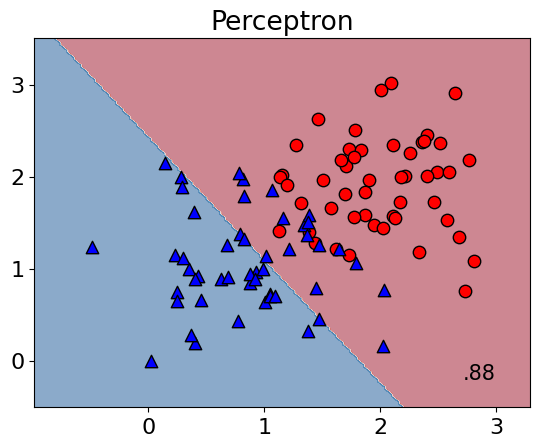

c:\Users\박중현\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but Perceptron was fitted with feature names
  warnings.warn(
C:\Users\박중현\AppData\Local\Temp\ipykernel_19052\2186397271.py:47: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  plt.scatter(X[Y==i].x, X[Y==i].y, facecolor=color, edgecolor='k', label=i, cmap=cm, marker=m, s=80)


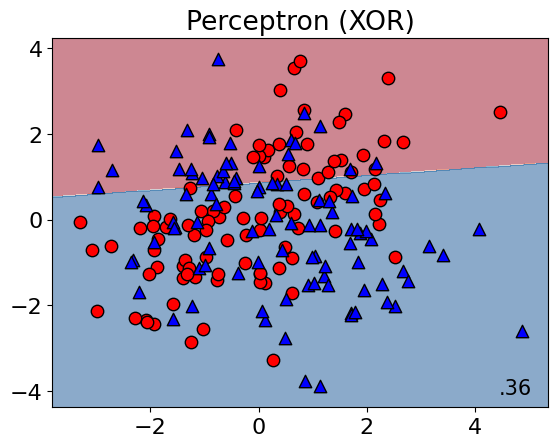

In [ ]:
from sklearn.linear_model import  Perceptron
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
from numpy.random import normal as rnorm
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt


plt.rcParams['font.size'] = 16

def plot_result(clf, clf_name, df, color = False):    
    X = df[['x','y']]
    Y = df['label']
    X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=.4, random_state=40)
    n_classes = len(Y.unique())
    if color == True:
        cm = plt.cm.RdBu
        plot_colors = "rbym"
    else:
        cm = plt.cm.Greys
        plot_colors = "wkym"
    plot_markers = "o^v*"
    plot_step = 0.02
    
    x_min, x_max = X.iloc[:, 0].min() - .5, X.iloc[:, 0].max() + .5
    y_min, y_max = X.iloc[:, 1].min() - .5, X.iloc[:, 1].max() + .5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step),
                             np.arange(y_min, y_max, plot_step))
    
    clf.fit(X_train,y_train)    
    score = clf.score(X_test, y_test)

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    cs = plt.contourf(xx, yy, Z, cmap=cm,  alpha=.5)

    # 학습에 쓰인 데이터 점을 플로팅
    for i, color, m in zip(range(n_classes), plot_colors, plot_markers):
        if color == True:
            plt.scatter(X[Y==i].x, X[Y==i].y, c=color, label=i, cmap=cm, marker=m, s=80)
        else:
            plt.scatter(X[Y==i].x, X[Y==i].y, facecolor=color, edgecolor='k', label=i, cmap=cm, marker=m, s=80)

    plt.text(xx.max() - .3, yy.min() + .3, ('%.2f' % score).lstrip('0'),
                    size=15, horizontalalignment='right')        
    plt.title(clf_name)
    
    
# 선형분리가능한 데이터의 예

from numpy.random import seed

seed(100)

N = 50
p1 = pd.DataFrame(np.hstack((rnorm(loc=2.0, scale=0.5, size=(N,1)), 
                              rnorm(loc=2.0, scale=0.5, size=(N,1)))),
                   columns=['x','y'])
p1['label'] = 0
p2 = pd.DataFrame(np.hstack((rnorm(loc=1.0, scale=0.5, size=(N,1)), 
                              rnorm(loc=1.0, scale=0.5, size=(N,1)))),
                   columns=['x','y'])
p2['label'] = 1
df = pd.concat([p1, p2])
# 선형분리가능하지 않은 데이터의 예(XOR 패턴)
N = 50
p1 = pd.DataFrame(np.hstack((rnorm(loc=1.0, scale=1.0, size=(N,1)), 
                              rnorm(loc=1.0, scale=1.0, size=(N,1)))),
                   columns=['x','y'])
p1['label'] = 0
p2 = pd.DataFrame(np.hstack((rnorm(loc=-1.0, scale=1.0, size=(N,1)), 
                              rnorm(loc=1.0, scale=1.0, size=(N,1)))),
                   columns=['x','y'])
p2['label'] = 1
p3 = pd.DataFrame(np.hstack((rnorm(loc=-1.0, scale=1.0, size=(N,1)), 
                              rnorm(loc=-1.0, scale=1.0, size=(N,1)))),
                   columns=['x','y'])
p3['label'] = 0
p4 = pd.DataFrame(np.hstack((rnorm(loc=1.0, scale=1.0, size=(N,1)), 
                              rnorm(loc=-1.0, scale=1.0, size=(N,1)))),
                   columns=['x','y'])
p4['label'] = 1
df_xor = pd.concat([p1,p2,p3,p4])

clf = Perceptron(max_iter=1000)

plot_result(clf, 'Perceptron', df, True)
plt.show()
plot_result(clf, 'Perceptron (XOR)', df_xor, True)

